# EDA — Young Adult

Exploración de datos para la categoría Young Adult. Buscamos describir concentración de popularidad, serialización, calidad de metadatos y solapamientos temáticos como parte de la naturaleza del dataset.

Este notebook es un **EDA diagnóstico**: busca entender forma, calidad, relaciones y rarezas del dato. No está organizado como notebook de CF ni de decisiones de modelado, y no documenta tareas de limpieza o procesamiento.

In [1]:
from pathlib import Path
import os
import sys
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BOOK_NUMERIC_COLUMNS, CATEGORIES
from src.utils.io import read_jsonl_sample
from src.utils.cleaning import _shelves_summary
from src.utils.eda import (
    schema_summary,
    duplicate_summary,
    numeric_profile,
    iqr_outlier_summary,
    categorical_profile,
    author_profile,
    shelves_profile,
    series_profile,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

## 1. Carga e inspección inicial

Arrancamos con una muestra controlada de libros e interacciones. Antes de interpretar nada, conviene mirar forma, columnas y algunos ejemplos crudos para entender qué tipo de objetos trae Goodreads.

In [2]:
CATEGORY = 'young_adult'
cfg = CATEGORIES[CATEGORY]
BOOKS_SAMPLE = 20_000
INTERACTIONS_SAMPLE = 100_000

print(cfg.books_file)
print(cfg.interactions_file)
print(f'Muestra de libros: {BOOKS_SAMPLE:,}')
print(f'Muestra de interacciones: {INTERACTIONS_SAMPLE:,}')

/home/nakato/projects/BigBook/data/raw/goodreads_books_young_adult.json.gz
/home/nakato/projects/BigBook/data/raw/goodreads_interactions_young_adult.json.gz
Muestra de libros: 20,000
Muestra de interacciones: 100,000


In [3]:
books_raw = read_jsonl_sample(cfg.books_file, nrows=BOOKS_SAMPLE)
interactions_raw = read_jsonl_sample(cfg.interactions_file, nrows=INTERACTIONS_SAMPLE)

print(f'books_raw: {books_raw.shape}')
print(f'interactions_raw: {interactions_raw.shape}')

preview_books = pd.DataFrame({'column': books_raw.columns, 'dtype_aparente': books_raw.dtypes.astype(str)})
preview_inter = pd.DataFrame({'column': interactions_raw.columns, 'dtype_aparente': interactions_raw.dtypes.astype(str)})

print(); print('Columnas en books_raw'); display(preview_books)
print(); print('Columnas en interactions_raw'); display(preview_inter)
print(); print('Ejemplo de libros crudos'); display(books_raw.head(3))
print(); print('Ejemplo de interacciones crudas'); display(interactions_raw.head(3))

books_raw: (20000, 29)
interactions_raw: (100000, 10)

Columnas en books_raw


,column,dtype_aparente
isbn,isbn,str
text_reviews_count,text_reviews_count,str
series,series,object
country_code,country_code,str
language_code,language_code,str
popular_shelves,popular_shelves,object
asin,asin,str
is_ebook,is_ebook,str
average_rating,average_rating,str
kindle_asin,kindle_asin,str



Columnas en interactions_raw


,column,dtype_aparente
user_id,user_id,str
book_id,book_id,str
review_id,review_id,str
is_read,is_read,bool
rating,rating,int64
review_text_incomplete,review_text_incomplete,str
date_added,date_added,str
date_updated,date_updated,str
read_at,read_at,str
started_at,started_at,str



Ejemplo de libros crudos


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,1,[147734],US,,"[{'count': '1057', 'name': 'to-read'}, {'count...",B0056A00P4,true,4.04,B0056A00P4,"[519546, 1295074, 21407416]",This is the final tale in the bestselling auth...,,https://www.goodreads.com/book/show/12182387-t...,"[{'author_id': '50873', 'role': ''}, {'author_...",,,,,,,,https://www.goodreads.com/book/show/12182387-t...,https://s.gr-assets.com/assets/nophoto/book/11...,12182387,4,285263,"The Passion (Dark Visions, #3)","The Passion (Dark Visions, #3)"
1,,2,[425995],US,,"[{'count': '1010', 'name': 'to-read'}, {'count...",B006KLYIAG,true,3.80,B006KLYIAG,"[13400912, 13327517, 18107102, 15797097, 11472...",Life should be simple for Cassie.\nFor the sma...,,https://www.goodreads.com/book/show/20135365-h...,"[{'author_id': '5395324', 'role': ''}]",,,,,,,,https://www.goodreads.com/book/show/20135365-h...,https://s.gr-assets.com/assets/nophoto/book/11...,20135365,5,18450480,Hope's Daughter,Hope's Daughter
2,0698143760,17,[493993],US,,"[{'count': '1799', 'name': 'fantasy'}, {'count...",,true,3.80,,"[15728807, 17182499, 15673520, 16081758, 17842...",Wanted by no one.\nHunted by everyone.\nSixtee...,ebook,https://www.goodreads.com/book/show/21401181-h...,"[{'author_id': '7314532', 'role': ''}]",Viking Children's,416,4,9780698143760,3,,2014,https://www.goodreads.com/book/show/21401181-h...,https://images.gr-assets.com/books/1394747643m...,21401181,33,24802827,"Half Bad (Half Life, #1)","Half Bad (Half Life, #1)"



Ejemplo de interacciones crudas


,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,18667753,be53fe83a6fc83474052f84692f6e90a,False,0,,Wed Mar 29 00:12:52 -0700 2017,Wed Mar 29 00:12:52 -0700 2017,,
1,8842281e1d1347389f2ab93d60773d4d,428263,2030f56879ebcc307a4b9cd8c83200e8,False,0,,Mon Mar 27 22:01:42 -0700 2017,Mon Mar 27 22:01:42 -0700 2017,,
2,8842281e1d1347389f2ab93d60773d4d,11387515,2fd3cd1acb30b099c135e358669639da,False,0,,Thu Jan 26 13:35:10 -0800 2017,Thu Jan 26 13:35:10 -0800 2017,,


## 2. Perfil general del dataset

A partir de acá armamos tablas analíticas de apoyo para describir el dato: esquema, nulos, cardinalidad, outliers y relaciones. El foco sigue siendo descriptivo.

In [4]:
def missing_with_empty_strings(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'nulls_raw': df.isna().sum(),
        'empty_strings_raw': df.astype('string').eq('').sum(),
        'non_null_raw': df.notna().sum(),
    })
    out['missing_like_total'] = out['nulls_raw'] + out['empty_strings_raw']
    out['missing_like_pct'] = out['missing_like_total'] / len(df) if len(df) else 0
    return out.sort_values(['missing_like_pct', 'empty_strings_raw'], ascending=False).reset_index(names='column')

books_num = books_raw.copy()
for col in BOOK_NUMERIC_COLUMNS:
    if col in books_num.columns:
        books_num[col] = pd.to_numeric(books_num[col], errors='coerce')

if 'popular_shelves' in books_num.columns:
    shelves_aux = books_num['popular_shelves'].map(lambda s: _shelves_summary(s, top_n=20)).apply(pd.Series)
    for col in ['shelf_count', 'to_read_count']:
        books_num[col] = shelves_aux[col]
if 'series' in books_num.columns:
    books_num['series_count'] = books_num['series'].map(lambda x: len(x) if isinstance(x, list) else 0)

interactions_num = interactions_raw.copy()
if 'rating' in interactions_num.columns:
    interactions_num['rating'] = pd.to_numeric(interactions_num['rating'], errors='coerce')
    interactions_num['rating_clean'] = interactions_num['rating'].where(interactions_num['rating'].between(1, 5), pd.NA)
    interactions_num['is_explicit'] = interactions_num['rating'].between(1, 5)
else:
    interactions_num['rating_clean'] = pd.NA
    interactions_num['is_explicit'] = False

for col in ['date_added', 'date_updated', 'read_at', 'started_at']:
    if col in interactions_num.columns:
        interactions_num[col] = pd.to_datetime(interactions_num[col], errors='coerce', utc=True)

interaction_agg = interactions_num.groupby('book_id', dropna=False).agg(
    interaction_count=('book_id', 'size'),
    explicit_rating_count=('rating_clean', lambda s: s.notna().sum()),
    mean_user_rating=('rating_clean', 'mean'),
).reset_index() if 'book_id' in interactions_num.columns else pd.DataFrame(columns=['book_id', 'interaction_count', 'explicit_rating_count', 'mean_user_rating'])

books_metrics = books_num.merge(interaction_agg, on='book_id', how='left') if 'book_id' in books_num.columns else books_num.copy()

summary = pd.DataFrame([
    {'metric': 'books_raw_rows', 'value': len(books_raw)},
    {'metric': 'interactions_raw_rows', 'value': len(interactions_raw)},
    {'metric': 'books_columns', 'value': books_raw.shape[1]},
    {'metric': 'interactions_columns', 'value': interactions_raw.shape[1]},
    {'metric': 'unique_book_id_books', 'value': books_raw['book_id'].nunique() if 'book_id' in books_raw.columns else np.nan},
    {'metric': 'unique_work_id_books', 'value': books_raw['work_id'].nunique() if 'work_id' in books_raw.columns else np.nan},
    {'metric': 'unique_user_id_interactions', 'value': interactions_raw['user_id'].nunique() if 'user_id' in interactions_raw.columns else np.nan},
    {'metric': 'explicit_rating_pct', 'value': interactions_num['is_explicit'].mean() if len(interactions_num) else np.nan},
])

books_schema = schema_summary(books_raw)
interactions_schema = schema_summary(interactions_raw)
books_missing_explicit = missing_with_empty_strings(books_raw)
interactions_missing_explicit = missing_with_empty_strings(interactions_raw)
duplicates = duplicate_summary(books_raw, interactions_raw)
books_numeric = numeric_profile(books_num, BOOK_NUMERIC_COLUMNS + ['shelf_count', 'to_read_count', 'series_count'])
interactions_numeric = numeric_profile(interactions_num, ['rating'])
books_outliers = iqr_outlier_summary(books_num, [c for c in BOOK_NUMERIC_COLUMNS + ['to_read_count', 'shelf_count', 'series_count'] if c in books_num.columns])
categoricals = categorical_profile(books_raw, ['language_code', 'format', 'publisher', 'country_code', 'is_ebook'])
author_artifacts = author_profile(books_raw)
shelf_artifacts = shelves_profile(books_raw, top_n=20)
series_artifacts = series_profile(books_raw)

In [5]:
print('Resumen general del muestreo')
display(summary)

Resumen general del muestreo


,metric,value
0,books_raw_rows,20000.00000
1,interactions_raw_rows,100000.00000
2,books_columns,29.00000
3,interactions_columns,10.00000
4,unique_book_id_books,20000.00000
5,unique_work_id_books,12891.00000
6,unique_user_id_interactions,1302.00000
7,explicit_rating_pct,0.42463


## 3. Esquema, nulos y vacíos

En Goodreads muchos faltantes aparecen como strings vacíos. Por eso miramos nulls y vacíos juntos antes de atribuir significado a la ausencia de un valor.

In [6]:
print('=== Esquema de books_raw ===')
display(books_schema)
print(); print('=== Esquema de interactions_raw ===')
display(interactions_schema)
print(); print('=== Books: nulls y vacíos efectivos ===')
display(books_missing_explicit.head(20))
print(); print('=== Interactions: nulls y vacíos efectivos ===')
display(interactions_missing_explicit.head(20))

=== Esquema de books_raw ===


,column,dtype,non_null,nulls,unique
0,asin,str,20000,0,3738
1,authors,object,20000,0,9525
2,average_rating,str,20000,0,255
3,book_id,str,20000,0,20000
4,country_code,str,20000,0,1
5,description,str,20000,0,17695
6,edition_information,str,20000,0,583
7,format,str,20000,0,63
8,image_url,str,20000,0,14680
9,is_ebook,str,20000,0,2



=== Esquema de interactions_raw ===


,column,dtype,non_null,nulls,unique
0,book_id,str,100000,0,18227
1,date_added,str,100000,0,98934
2,date_updated,str,100000,0,98635
3,is_read,bool,100000,0,2
4,rating,int64,100000,0,6
5,read_at,str,100000,0,15448
6,review_id,str,100000,0,100000
7,review_text_incomplete,str,100000,0,7822
8,started_at,str,100000,0,10703
9,user_id,str,100000,0,1302



=== Books: nulls y vacíos efectivos ===


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
0,edition_information,str,0,18432,20000,18432,0.9216
1,asin,str,0,16263,20000,16263,0.81315
2,kindle_asin,str,0,10299,20000,10299,0.51495
3,isbn,str,0,8014,20000,8014,0.4007
4,language_code,str,0,6387,20000,6387,0.31935
5,publication_day,str,0,6126,20000,6126,0.3063
6,isbn13,str,0,5735,20000,5735,0.28675
7,publication_month,str,0,4764,20000,4764,0.2382
8,num_pages,str,0,4642,20000,4642,0.2321
9,publisher,str,0,4041,20000,4041,0.20205



=== Interactions: nulls y vacíos efectivos ===


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
0,review_text_incomplete,str,0,92078,100000,92078,0.92078
1,started_at,str,0,82228,100000,82228,0.82228
2,read_at,str,0,77945,100000,77945,0.77945
3,user_id,str,0,0,100000,0,0.0
4,book_id,str,0,0,100000,0,0.0
5,review_id,str,0,0,100000,0,0.0
6,is_read,bool,0,0,100000,0,0.0
7,rating,int64,0,0,100000,0,0.0
8,date_added,str,0,0,100000,0,0.0
9,date_updated,str,0,0,100000,0,0.0


In [7]:
if 'rating' in interactions_raw.columns:
    rating_dist = interactions_raw['rating'].value_counts(dropna=False).sort_index().rename_axis('rating').reset_index(name='count')
    rating_dist['pct'] = rating_dist['count'] / len(interactions_raw)
    print('Distribución observada de rating')
    display(rating_dist)

print(); print('Ejemplos de campos anidados en books_raw')
display(books_raw[['authors', 'popular_shelves', 'series']].head(2))

Distribución observada de rating


,rating,count,pct
0,0,57537,0.57537
1,1,996,0.00996
2,2,2946,0.02946
3,3,9876,0.09876
4,4,15434,0.15434
5,5,13211,0.13211



Ejemplos de campos anidados en books_raw


,authors,popular_shelves,series
0,"[{'author_id': '50873', 'role': ''}, {'author_...","[{'count': '1057', 'name': 'to-read'}, {'count...",[147734]
1,"[{'author_id': '5395324', 'role': ''}]","[{'count': '1010', 'name': 'to-read'}, {'count...",[425995]


## 4. Duplicados y llaves

En libros, `book_id` y `work_id` no cuentan lo mismo: uno identifica edición/registro y el otro obra. En interacciones, interesa saber si un review o un par usuario-libro aparece más de una vez.

In [8]:
display(duplicates)

if 'work_id' in books_raw.columns:
    repeated_works = (
        books_raw.groupby('work_id', dropna=False)
        .size()
        .rename('edition_count')
        .reset_index()
        .sort_values('edition_count', ascending=False)
    )
    print(); print('Obras con más ediciones/entradas en la muestra')
    display(repeated_works.head(15))

,key,duplicates,records
0,books.book_id,0,20000
1,books.work_id,7109,20000
2,interactions.review_id,0,100000
3,interactions.user_id_book_id,0,100000



Obras con más ediciones/entradas en la muestra


,work_id,edition_count
4602,2267189,28
5908,2588213,28
7086,3346751,24
6963,3212258,23
11678,6171458,22
12688,8812783,22
79,10342808,21
2165,16827462,20
7096,335933,20
318,11138426,19


## 5. Variables numéricas y outliers

Acá el punto no es quitar atípicos por defecto, sino entender de qué tipo son. En Goodreads un valor extremo puede significar error, reedición rara o, muy seguido, cola larga natural de popularidad.

Perfil numérico de libros


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,text_reviews_count,20000.0,97.664200,930.884795,0.0,1.00,1.0,3.00,9.00,30.00,263.00,1549.04,86946.0
1,average_rating,20000.0,3.861994,0.348084,0.0,2.97,3.3,3.66,3.87,4.09,4.39,4.61,5.0
2,num_pages,15358.0,296.686287,131.619111,0.0,6.57,82.0,224.00,296.00,368.00,496.00,653.86,2039.0
3,publication_day,13874.0,12.551247,9.664926,1.0,1.00,1.0,3.00,11.00,21.00,29.00,31.00,31.0
4,publication_month,15236.0,6.291940,3.310151,1.0,1.00,1.0,3.00,6.00,9.00,12.00,12.00,12.0
5,publication_year,16600.0,2011.129819,145.394694,12.0,1984.00,1998.0,2010.00,2012.00,2015.00,2017.00,2017.00,20045.0
6,ratings_count,20000.0,1196.738100,16503.031247,0.0,1.00,3.0,15.00,48.00,189.00,2247.00,18375.30,1743362.0
7,shelf_count,20000.0,87.474950,25.476543,4.0,12.00,24.0,100.00,100.00,100.00,100.00,100.00,100.0
8,to_read_count,19881.0,11097.922338,40789.545415,1.0,6.00,23.0,229.00,1213.00,5439.00,46324.00,213303.00,543151.0
9,series_count,20000.0,0.623950,0.575806,0.0,0.00,0.0,0.00,1.00,1.00,1.00,2.00,4.0



Perfil numérico de interacciones


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,rating,100000.0,1.64307,2.022175,0.0,0.0,0.0,0.0,0.0,4.0,5.0,5.0,5.0



Resumen IQR de outliers en libros


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,text_reviews_count,3.00,30.00,27.00,263.00,1549.04,70.500,2702
1,average_rating,3.66,4.09,0.43,4.39,4.61,4.735,77
2,num_pages,224.00,368.00,144.00,496.00,653.86,584.000,274
3,publication_day,3.00,21.00,18.00,29.00,31.00,48.000,0
4,publication_month,3.00,9.00,6.00,12.00,12.00,18.000,0
5,publication_year,2010.00,2015.00,5.00,2017.00,2017.00,2022.500,3
6,ratings_count,15.00,189.00,174.00,2247.00,18375.30,450.000,2983
7,to_read_count,229.00,5439.00,5210.00,46324.00,213303.00,13254.000,2821
8,shelf_count,100.00,100.00,0.00,100.00,100.00,100.000,0
9,series_count,0.00,1.00,1.00,1.00,2.00,2.500,126


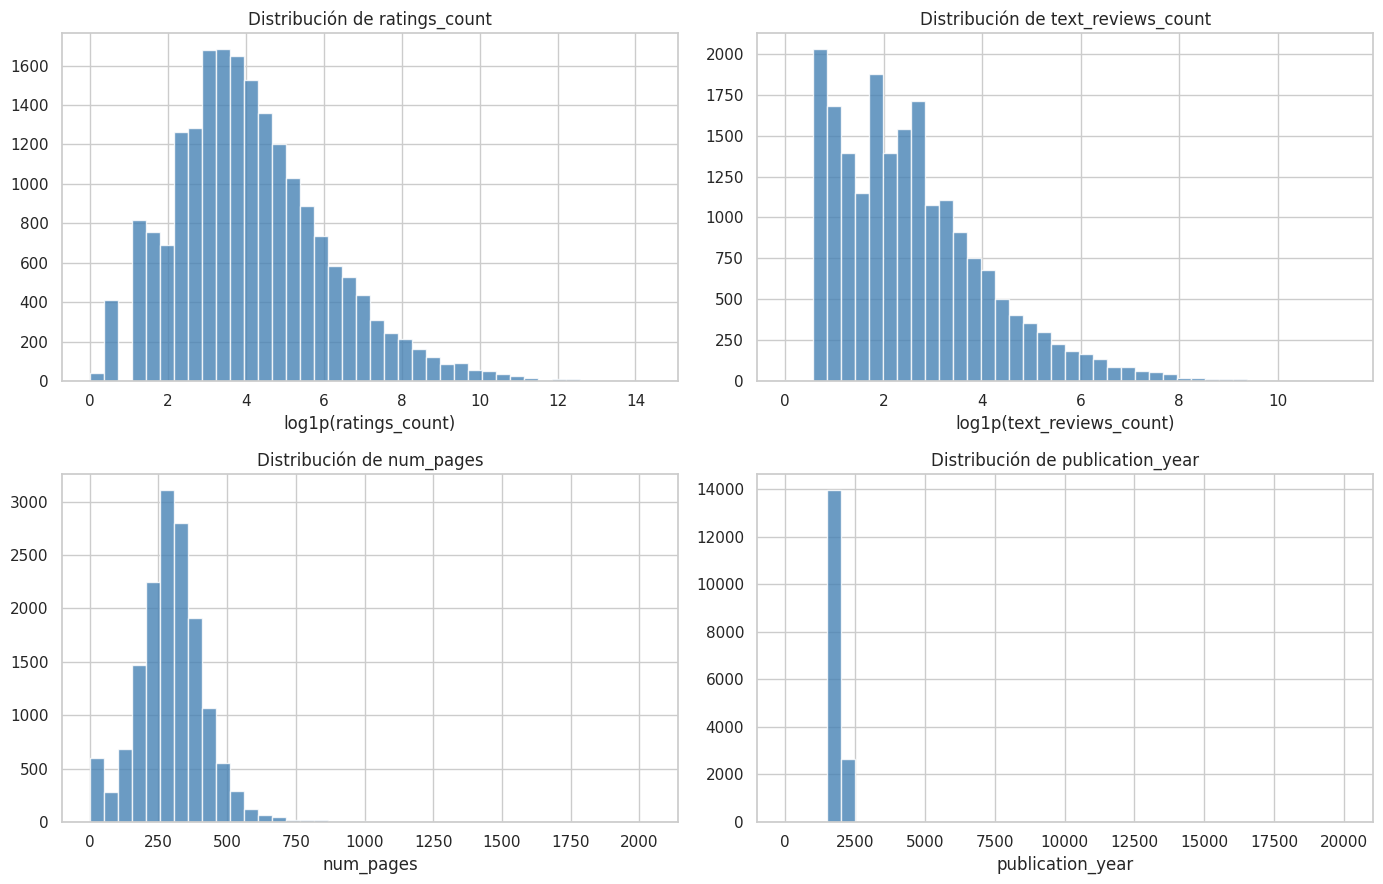

In [9]:
print('Perfil numérico de libros')
display(books_numeric)
print(); print('Perfil numérico de interacciones')
display(interactions_numeric)
print(); print('Resumen IQR de outliers en libros')
display(books_outliers)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plots = [
    ('ratings_count', 'Distribución de ratings_count', True),
    ('text_reviews_count', 'Distribución de text_reviews_count', True),
    ('num_pages', 'Distribución de num_pages', False),
    ('publication_year', 'Distribución de publication_year', False),
]
for ax, (col, title, use_log) in zip(axes.ravel(), plots):
    if col in books_num.columns:
        vals = pd.to_numeric(books_num[col], errors='coerce').dropna()
        if use_log:
            vals = np.log1p(vals)
            ax.set_xlabel(f'log1p({col})')
        else:
            ax.set_xlabel(col)
        ax.hist(vals, bins=40, color='steelblue', alpha=0.8)
        ax.set_title(title)
plt.tight_layout()
plt.show()

In [10]:
cols_contexto = [c for c in ['book_id', 'work_id', 'title', 'publication_year', 'ratings_count', 'text_reviews_count', 'num_pages', 'average_rating'] if c in books_num.columns]
print('Libros más populares en la muestra')
display(books_num[cols_contexto].sort_values('ratings_count', ascending=False).head(15))
print(); print('Libros más largos en la muestra')
display(books_num[cols_contexto].sort_values('num_pages', ascending=False).head(15))

Libros más populares en la muestra


,book_id,work_id,title,publication_year,ratings_count,text_reviews_count,num_pages,average_rating
5427,7260188,8812783,"Mockingjay (The Hunger Games, #3)",2010.0,1743362,86946,392.0,4.03
19151,1217100,2588213,Thirteen Reasons Why,NaN,465848,30726,288.0,4.02
4754,6339664,6525609,"Hush, Hush (Hush, Hush, #1)",2009.0,457299,20227,391.0,3.99
7675,6487308,6678670,"Fallen (Fallen, #1)",2009.0,402552,16254,452.0,3.74
15544,4502507,4551489,The Last Olympian (Percy Jackson and the Olymp...,2009.0,398036,11783,11.0,4.50
14667,439288,118521,Speak,2001.0,367367,16886,208.0,4.00
7853,16068905,21861351,Fangirl,2013.0,357140,31882,481.0,4.12
13371,28194,2628323,"Inkheart (Inkworld, #1)",2005.0,288143,8686,548.0,3.86
14906,16143347,21975829,We Were Liars,2014.0,284775,31690,242.0,3.85
8286,16101128,19187812,"The 5th Wave (The 5th Wave, #1)",2013.0,270771,22880,457.0,4.10



Libros más largos en la muestra


,book_id,work_id,title,publication_year,ratings_count,text_reviews_count,num_pages,average_rating
10185,17984302,40697560,Percy Jackson: Percy-Jackson-Schuber - inkl. E...,2012.0,44,2,2039.0,4.57
3808,12398780,17409955,"The Alex Rider Boxed Set, #1-9 (Alex Rider #1-9)",2011.0,481,14,2000.0,4.49
6392,22666215,40332073,The Divergent Library: Divergent; Insurgent; A...,NaN,885,28,1888.0,4.50
1745,20957429,40332073,The Divergent Library: Divergent; Insurgent; A...,2014.0,1689,50,1838.0,4.50
12646,6443349,40697560,Percy Jackson and the Olympians Boxed Set (Per...,2009.0,20008,745,1744.0,4.57
9401,7007561,45379343,Gregor the Overlander Box Set (Underland Chron...,2009.0,3098,247,1733.0,4.46
13958,6277640,6461158,"Uglies, The Collector's Set (Uglies, #1-4)",2009.0,6580,219,1680.0,4.22
17135,20759464,19239106,The Infernal Devices: Clockwork Angel; Clockwo...,2014.0,62,2,1648.0,4.68
14590,22698031,42215238,Divergent Series Box Set (Books 1-4 Plus World...,2014.0,936,25,1616.0,4.48
19590,18599602,26127326,"Bloedbelofte, Geestesband, Offergave (Vampire ...",2013.0,19,2,1560.0,4.59


## 6. Variables categóricas y estructuras anidadas

Goodreads guarda mucha señal útil en listas y taxonomías de usuario. `authors`, `popular_shelves` y `series` merecen inspección propia porque explican parte de la forma del catálogo.

Top de variables categóricas observadas


,column,value,count,pct
0,language_code,eng,7711,0.38555
1,language_code,,6387,0.31935
2,language_code,en-US,1087,0.05435
3,language_code,en-GB,660,0.03300
4,language_code,ger,621,0.03105
5,language_code,spa,535,0.02675
6,language_code,ita,364,0.01820
7,language_code,ind,355,0.01775
8,language_code,fre,354,0.01770
9,language_code,nl,329,0.01645



Distribución de roles del autor principal


,role,books,pct
0,<blank>,19769,0.98845
1,Creator,86,0.00430
2,Editor,66,0.00330
3,Pseudonym,13,0.00065
4,Author,7,0.00035
5,creator,6,0.00030
6,Contributor,4,0.00020
7,author,4,0.00020
8,Illustrations,3,0.00015
9,pseudonym,3,0.00015



Top shelves observadas


,shelf_name,book_count
0,to-read,19881
1,young-adult,19424
2,currently-reading,18177
3,ya,17455
4,fiction,16081
5,favorites,15695
6,books-i-own,15156
7,owned,14917
8,romance,13245
9,teen,12975



Standalone vs series


,group,books,pct
0,standalone,8260,0.413
1,in_series,11740,0.587



Distribución de cantidad de series asociadas por libro


,series_count,books,pct
0,0,8260,0.41300
1,1,11179,0.55895
2,2,435,0.02175
3,3,74,0.00370
4,4,52,0.00260


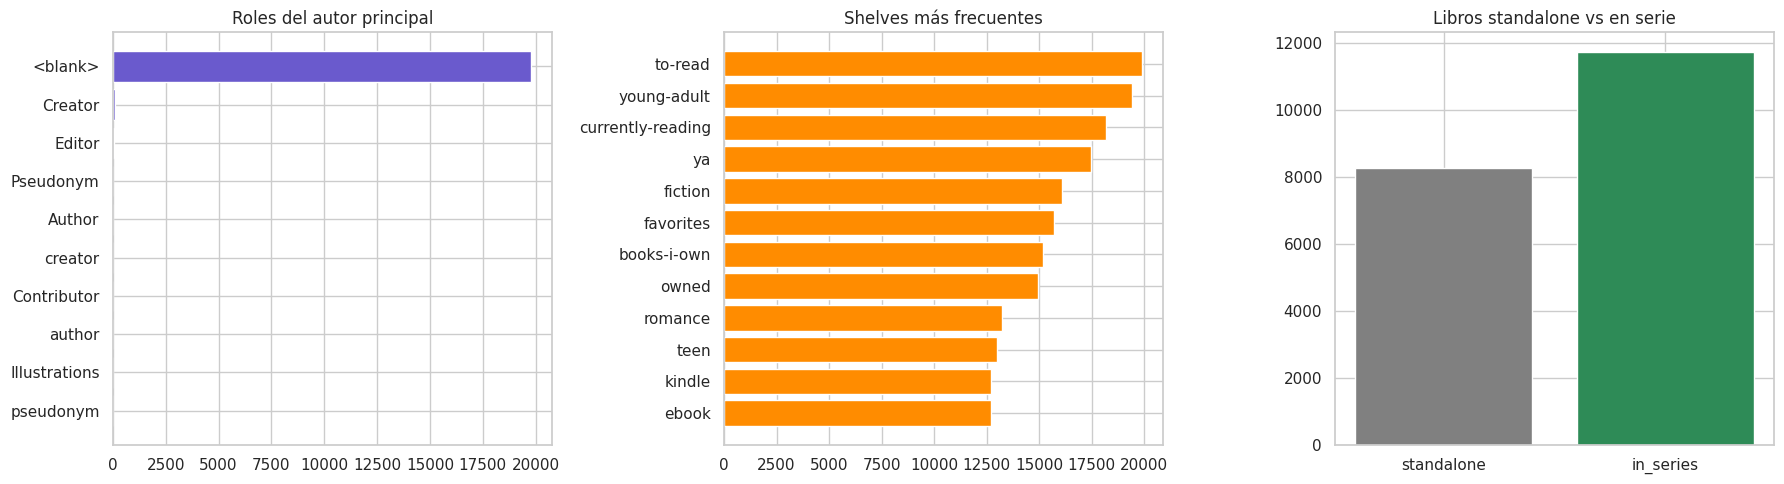

In [11]:
print('Top de variables categóricas observadas')
display(categoricals.head(20))
print(); print('Distribución de roles del autor principal')
display(author_artifacts['role_dist'].head(20))
print(); print('Top shelves observadas')
display(shelf_artifacts['top_shelf_names'].head(20))
print(); print('Standalone vs series')
display(series_artifacts['standalone_vs_series'])
print(); print('Distribución de cantidad de series asociadas por libro')
display(series_artifacts['series_length_dist'].head(15))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_roles = author_artifacts['role_dist'].head(10).iloc[::-1]
axes[0].barh(top_roles['role'], top_roles['books'], color='slateblue')
axes[0].set_title('Roles del autor principal')

top_shelves = shelf_artifacts['top_shelf_names'].head(12).iloc[::-1]
axes[1].barh(top_shelves['shelf_name'], top_shelves['book_count'], color='darkorange')
axes[1].set_title('Shelves más frecuentes')

series_view = series_artifacts['standalone_vs_series']
axes[2].bar(series_view['group'], series_view['books'], color=['grey', 'seagreen'])
axes[2].set_title('Libros standalone vs en serie')
plt.tight_layout()
plt.show()

## 7. Relaciones entre variables

Ahora sí pasamos de describir columnas a mirar relaciones. Interesan especialmente los vínculos entre demanda, popularidad, longitud, serialización y rating promedio, separando correlaciones plausibles de artefactos editoriales o de exposición.

,average_rating,ratings_count,text_reviews_count,to_read_count,interaction_count,explicit_rating_count,mean_user_rating,series_count,num_pages
average_rating,1.000,0.025,0.025,0.115,0.070,0.063,0.322,0.248,0.234
ratings_count,0.025,1.000,0.939,0.042,0.915,0.980,0.026,0.035,0.029
text_reviews_count,0.025,0.939,1.000,0.067,0.940,0.939,0.033,0.023,0.042
to_read_count,0.115,0.042,0.067,1.000,0.141,0.117,0.031,0.081,0.118
interaction_count,0.070,0.915,0.940,0.141,1.000,0.945,0.039,0.080,0.086
explicit_rating_count,0.063,0.980,0.939,0.117,0.945,1.000,0.029,0.081,0.050
mean_user_rating,0.322,0.026,0.033,0.031,0.039,0.029,1.000,0.096,0.102
series_count,0.248,0.035,0.023,0.081,0.080,0.081,0.096,1.000,0.150
num_pages,0.234,0.029,0.042,0.118,0.086,0.050,0.102,0.150,1.000


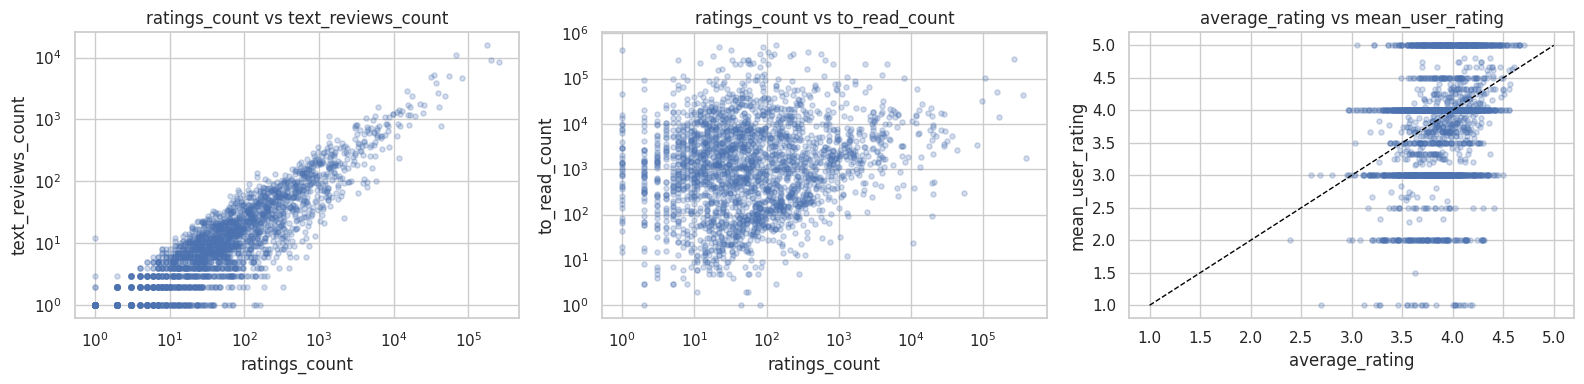

In [12]:
for col in ['ratings_count', 'text_reviews_count', 'to_read_count', 'interaction_count', 'explicit_rating_count', 'mean_user_rating', 'series_count', 'num_pages', 'average_rating']:
    if col in books_metrics.columns:
        books_metrics[col] = pd.to_numeric(books_metrics[col], errors='coerce')

corr_cols = [
    'average_rating', 'ratings_count', 'text_reviews_count', 'to_read_count',
    'interaction_count', 'explicit_rating_count', 'mean_user_rating',
    'series_count', 'num_pages'
]
corr_cols = [c for c in corr_cols if c in books_metrics.columns]
corr = books_metrics[corr_cols].corr(numeric_only=True)
display(corr.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plots = [
    ('ratings_count', 'text_reviews_count', 'ratings_count vs text_reviews_count'),
    ('ratings_count', 'to_read_count', 'ratings_count vs to_read_count'),
    ('average_rating', 'mean_user_rating', 'average_rating vs mean_user_rating'),
]
for ax, (x, y, title) in zip(axes, plots):
    if x in books_metrics.columns and y in books_metrics.columns:
        sample_base = books_metrics[[x, y]].dropna()
        sample = sample_base.sample(min(2500, len(sample_base)), random_state=42) if len(sample_base) else sample_base
        ax.scatter(sample[x], sample[y], alpha=0.25, s=14)
        ax.set_title(title)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        if x in {'ratings_count', 'text_reviews_count', 'to_read_count'}:
            ax.set_xscale('log')
        if y in {'ratings_count', 'text_reviews_count', 'to_read_count'}:
            ax.set_yscale('log')
        if x == 'average_rating' and y == 'mean_user_rating' and len(sample):
            lo = max(1, min(sample[x].min(), sample[y].min()))
            hi = min(5, max(sample[x].max(), sample[y].max()))
            ax.plot([lo, hi], [lo, hi], linestyle='--', color='black', linewidth=1)
plt.tight_layout()
plt.show()

## 8. Naturaleza de las interacciones

Las interacciones también tienen su propia forma: lectura marcada, reseña vacía, rating explícito o rating ausente. Esto sirve para entender qué parte del comportamiento del usuario está realmente observada.

,mode,interactions,pct
0,shelf_only,54948,0.54948
1,rating_only,34842,0.34842
2,review,7922,0.07922
3,read_no_rating,2288,0.02288



Duración de lectura válida (0 a 365 días)


,stat,value
0,count,16328.000000
1,mean,10.686000
2,std,31.288741
3,min,0.000000
4,25%,1.000000
5,50%,3.000000
6,75%,7.000000
7,90%,20.000000
8,95%,40.000000
9,max,365.000000



Sesgo promedio de usuarios con >=3 ratings explícitos


,user_type,users,pct
0,generous,630,0.612840
1,balanced,335,0.325875
2,strict,63,0.061284



Crecimiento temporal de interacciones


,year,new_interactions
0,2006,1
1,2007,27
2,2008,1218
3,2009,1136
4,2010,1208
5,2011,1265
6,2012,26570
7,2013,17670
8,2014,13912
9,2015,15045


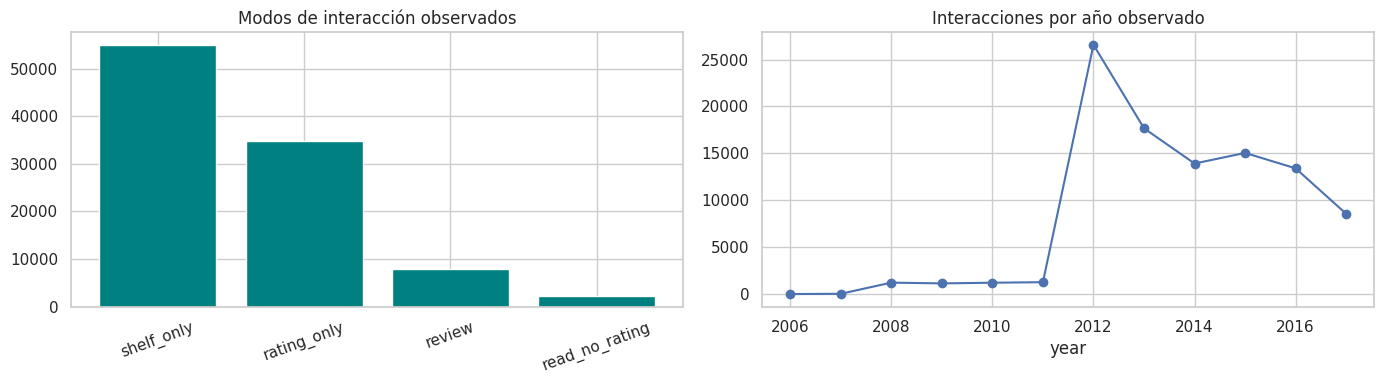

In [13]:
mode_rows = []
if len(interactions_num):
    has_review = interactions_raw['review_text_incomplete'].astype('string').str.strip().ne('') if 'review_text_incomplete' in interactions_raw.columns else pd.Series(False, index=interactions_num.index)
    has_rating = interactions_num['rating_clean'].notna()
    is_read = interactions_raw['is_read'].fillna(False).astype(bool) if 'is_read' in interactions_raw.columns else pd.Series(False, index=interactions_num.index)
    modes = pd.Series(np.select([has_review, has_rating, is_read], ['review', 'rating_only', 'read_no_rating'], 'shelf_only'))
    mode_dist = modes.value_counts().reset_index()
    mode_dist.columns = ['mode', 'interactions']
    mode_dist['pct'] = mode_dist['interactions'] / len(interactions_num)
else:
    mode_dist = pd.DataFrame(columns=['mode', 'interactions', 'pct'])
display(mode_dist)

duration = pd.Series(dtype='float64')
if {'started_at', 'read_at'}.issubset(interactions_num.columns):
    duration = (interactions_num['read_at'] - interactions_num['started_at']).dt.days
    duration = duration.where(duration.between(0, 365)).dropna()
duration_stats = duration.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('value').reset_index().rename(columns={'index': 'stat'}) if not duration.empty else pd.DataFrame(columns=['stat', 'value'])
print(); print('Duración de lectura válida (0 a 365 días)')
display(duration_stats)

user_bias = pd.DataFrame(columns=['user_type', 'users', 'pct'])
if 'user_id' in interactions_num.columns:
    rated = interactions_num.dropna(subset=['rating_clean'])
    if len(rated):
        counts = rated.groupby('user_id')['rating_clean'].size()
        means = rated.groupby('user_id')['rating_clean'].mean()
        eligible = pd.DataFrame({'count': counts, 'mean': means})
        eligible = eligible[eligible['count'] >= 3]
        labels = np.select([eligible['mean'] < 3, eligible['mean'] < 3.67], ['strict', 'balanced'], 'generous') if len(eligible) else []
        user_bias = pd.Series(labels).value_counts().reset_index()
        user_bias.columns = ['user_type', 'users']
        user_bias['pct'] = user_bias['users'] / len(eligible) if len(eligible) else np.nan
print(); print('Sesgo promedio de usuarios con >=3 ratings explícitos')
display(user_bias)

growth = pd.DataFrame(columns=['year', 'new_interactions'])
if 'date_added' in interactions_num.columns:
    tmp = interactions_num.dropna(subset=['date_added']).copy()
    if len(tmp):
        tmp['year'] = tmp['date_added'].dt.year
        growth = tmp.groupby('year').size().reset_index(name='new_interactions').sort_values('year')
print(); print('Crecimiento temporal de interacciones')
display(growth.tail(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(mode_dist['mode'], mode_dist['interactions'], color='teal')
axes[0].set_title('Modos de interacción observados')
axes[0].tick_params(axis='x', rotation=20)
if len(growth):
    axes[1].plot(growth['year'], growth['new_interactions'], marker='o')
    axes[1].set_title('Interacciones por año observado')
    axes[1].set_xlabel('year')
plt.tight_layout()
plt.show()

## 9. Profundización específica — Young Adult

En Young Adult el perfil base mostró mucha repetición de `work_id`, fuerte presencia de series y atípicos de popularidad especialmente intensos. La profundización se centra en concentración del catálogo, solapamiento YA / middle grade y contexto de los outliers más fuertes.

In [14]:
YA_GROUPS = {
    'ya_fantasy': ['ya-fantasy', 'fantasy-ya', 'fantasy'],
    'ya_dystopia': ['dystopia', 'dystopian', 'post-apocalyptic'],
    'ya_contemporary': ['ya-contemporary', 'contemporary', 'realistic-fiction'],
    'ya_romance': ['ya-romance', 'teen-romance', 'romance'],
    'ya_paranormal': ['paranormal', 'supernatural', 'vampires', 'werewolves'],
    'ya_scifi': ['science-fiction', 'sci-fi', 'science-fiction-ya'],
    'middle_grade': ['middle-grade', 'childrens', 'juvenile', 'kids'],
    'coming_of_age': ['coming-of-age', 'bildungsroman', 'teen', 'teens'],
}

def assign_theme_flags(shelves_list, theme_map):
    names = set()
    if isinstance(shelves_list, list):
        for item in shelves_list:
            if isinstance(item, dict) and item.get('name'):
                names.add(str(item['name']).lower())
    return {theme: any(any(keyword in shelf for shelf in names) for keyword in keywords) for theme, keywords in theme_map.items()}

ya_flags_raw = pd.concat([
    books_raw[['book_id']].reset_index(drop=True),
    books_raw['popular_shelves'].apply(lambda s: assign_theme_flags(s, YA_GROUPS)).apply(pd.Series).reset_index(drop=True),
], axis=1)

ya_theme_books = books_metrics[['book_id', 'title', 'work_id', 'publication_year', 'ratings_count', 'interaction_count', 'series_count', 'to_read_count']].merge(ya_flags_raw, on='book_id', how='left')

counts = ya_theme_books['ratings_count'].fillna(0).sort_values(ascending=False)
concentration = pd.DataFrame([
    {'top_frac': frac, 'top_books': max(1, int(len(counts) * frac)), 'ratings_share': counts.head(max(1, int(len(counts) * frac))).sum() / counts.sum() if counts.sum() else np.nan}
    for frac in [0.01, 0.05, 0.10]
])
display(concentration)

theme_rows = []
for theme in YA_GROUPS:
    subset = ya_theme_books[ya_theme_books[theme].fillna(False)]
    if len(subset):
        theme_rows.append({
            'theme': theme,
            'books': len(subset),
            'pct_books': len(subset) / len(ya_theme_books),
            'median_ratings_count': subset['ratings_count'].median(),
            'median_interaction_count': subset['interaction_count'].median(),
            'pct_in_series': subset['series_count'].gt(0).mean(),
        })

theme_summary = pd.DataFrame(theme_rows).sort_values('books', ascending=False)
display(theme_summary)

,top_frac,top_books,ratings_share
0,0.01,200,0.663229
1,0.05,1000,0.865846
2,0.10,2000,0.922283


,theme,books,pct_books,median_ratings_count,median_interaction_count,pct_in_series
7,coming_of_age,15925,0.79625,56.0,2.0,0.601947
3,ya_romance,14020,0.70100,56.0,2.0,0.647860
2,ya_contemporary,11878,0.59390,56.0,2.0,0.498653
0,ya_fantasy,11066,0.55330,49.0,2.0,0.769836
4,ya_paranormal,7958,0.39790,52.0,2.0,0.796306
5,ya_scifi,7740,0.38700,50.0,2.0,0.805685
6,middle_grade,5357,0.26785,55.0,1.0,0.561882
1,ya_dystopia,4291,0.21455,51.0,2.0,0.820555


In [15]:
jaccard_rows = []
for left, right in combinations(YA_GROUPS.keys(), 2):
    left_books = set(ya_theme_books.loc[ya_theme_books[left].fillna(False), 'book_id'])
    right_books = set(ya_theme_books.loc[ya_theme_books[right].fillna(False), 'book_id'])
    union = left_books | right_books
    if union:
        jaccard_rows.append({'theme_a': left, 'theme_b': right, 'jaccard_books': len(left_books & right_books) / len(union)})

jaccard_df = pd.DataFrame(jaccard_rows).sort_values('jaccard_books', ascending=False)
print('Solapamientos más altos entre etiquetas YA y middle grade')
display(jaccard_df.head(15))

popular_ya = ya_theme_books.sort_values('ratings_count', ascending=False).copy()
popular_ya['theme_principal'] = popular_ya[[c for c in YA_GROUPS.keys()]].fillna(False).idxmax(axis=1)
popular_ya.loc[~popular_ya[[c for c in YA_GROUPS.keys()]].fillna(False).any(axis=1), 'theme_principal'] = 'sin_grupo_claro'
display(popular_ya[['title', 'theme_principal', 'publication_year', 'ratings_count', 'interaction_count', 'series_count']].head(20))

Solapamientos más altos entre etiquetas YA y middle grade


,theme_a,theme_b,jaccard_books
3,ya_fantasy,ya_paranormal,0.674648
21,ya_romance,coming_of_age,0.664258
4,ya_fantasy,ya_scifi,0.644025
17,ya_contemporary,coming_of_age,0.605625
13,ya_contemporary,ya_romance,0.532245
6,ya_fantasy,coming_of_age,0.492040
2,ya_fantasy,ya_romance,0.491261
10,ya_dystopia,ya_scifi,0.491015
22,ya_paranormal,ya_scifi,0.466692
18,ya_romance,ya_paranormal,0.408846


,title,theme_principal,publication_year,ratings_count,interaction_count,series_count
5427,"Mockingjay (The Hunger Games, #3)",ya_fantasy,2010.0,1743362,553.0,1
19151,Thirteen Reasons Why,ya_contemporary,NaN,465848,183.0,0
4754,"Hush, Hush (Hush, Hush, #1)",ya_fantasy,2009.0,457299,181.0,1
7675,"Fallen (Fallen, #1)",ya_fantasy,2009.0,402552,175.0,1
15544,The Last Olympian (Percy Jackson and the Olymp...,ya_fantasy,2009.0,398036,136.0,2
14667,Speak,ya_contemporary,2001.0,367367,163.0,0
7853,Fangirl,ya_contemporary,2013.0,357140,167.0,0
13371,"Inkheart (Inkworld, #1)",ya_fantasy,2005.0,288143,139.0,1
14906,We Were Liars,ya_contemporary,2014.0,284775,165.0,0
8286,"The 5th Wave (The 5th Wave, #1)",ya_fantasy,2013.0,270771,128.0,1


## 10. Hallazgos y riesgos de interpretación

Cerramos con un resumen de lectura EDA: qué parece estructural del género, qué columnas son frágiles, dónde hay rarezas válidas y qué conviene tratar con cuidado en cualquier análisis posterior.

In [16]:
specific_takeaway = 'Young Adult muestra una concentración muy fuerte de popularidad y mucho solapamiento entre etiquetas; las franquicias y múltiples ediciones pesan bastante en la forma observable del género.'

zero_rating_pct = interactions_num['rating'].eq(0).mean() if 'rating' in interactions_num.columns else np.nan
review_blank_pct = interactions_missing_explicit.loc[
    interactions_missing_explicit['column'].eq('review_text_incomplete'),
    'missing_like_pct'
].iloc[0] if 'review_text_incomplete' in interactions_missing_explicit['column'].values else np.nan
work_dup_pct = books_raw['work_id'].duplicated().mean() if 'work_id' in books_raw.columns else np.nan
series_pct = series_artifacts['standalone_vs_series'].loc[
    series_artifacts['standalone_vs_series']['group'].eq('in_series'), 'pct'
].iloc[0]

hallazgos = pd.DataFrame([
    {'tema': 'Muestreo y forma', 'hallazgo': f"Se analizaron {len(books_raw):,} libros y {len(interactions_raw):,} interacciones del género."},
    {'tema': 'Metadatos faltantes', 'hallazgo': f"Los vacíos se concentran en campos editoriales y de identificación; `rating = 0` representa {zero_rating_pct:.1%} de las interacciones observadas."},
    {'tema': 'Texto de reseña', 'hallazgo': f"`review_text_incomplete` está vacío en {review_blank_pct:.1%} de la muestra; la huella textual existe, pero es minoritaria frente al evento de lectura o shelving."},
    {'tema': 'Ediciones y obras', 'hallazgo': f"`work_id` se repite en {work_dup_pct:.1%} de los registros de libros de la muestra, lo que sugiere convivencia de múltiples ediciones para una misma obra."},
    {'tema': 'Series', 'hallazgo': f"El {series_pct:.1%} de los libros cae dentro de alguna serie en esta muestra, así que la serialización forma parte de la naturaleza del catálogo."},
    {'tema': 'Outliers', 'hallazgo': 'Los atípicos aparecen sobre todo en métricas de popularidad (`ratings_count`, `text_reviews_count`) y suelen comportarse como cola larga natural, no como errores automáticos.'},
    {'tema': 'Relaciones', 'hallazgo': 'Las variables de demanda tienden a moverse juntas, mientras que la calidad percibida (`average_rating`) explica solo una parte del volumen de interacción.'},
    {'tema': 'Lectura EDA', 'hallazgo': specific_takeaway},
])

display(hallazgos)

,tema,hallazgo
0,Muestreo y forma,"Se analizaron 20,000 libros y 100,000 interacc..."
1,Metadatos faltantes,Los vacíos se concentran en campos editoriales...
2,Texto de reseña,`review_text_incomplete` está vacío en 92.1% d...
3,Ediciones y obras,`work_id` se repite en 35.5% de los registros ...
4,Series,El 58.7% de los libros cae dentro de alguna se...
5,Outliers,Los atípicos aparecen sobre todo en métricas d...
6,Relaciones,Las variables de demanda tienden a moverse jun...
7,Lectura EDA,Young Adult muestra una concentración muy fuer...
